##House Price Regression

**Problem Statement**

The real estate industry often needs accurate estimation of property prices based on various house characteristics. In this task, the goal is to build a Machine Learning regression model that predicts the price of a house using features such as house size, number of bedrooms, number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was built.
Students are required to analyze the dataset, perform data preprocessing, apply feature engineering techniques, train multiple regression models, and evaluate their performance to identify the best model for predicting house prices.


**Objective**

The objective of this task is to:

1. Understand and explore the housing dataset.
  
2.  Perform data preprocessing including handling missing values, duplicates, and outliers.

3. Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the data.

4. Apply encoding, log transformation, and feature scaling where    necessary.

5. Train multiple regression algorithms to predict house prices.
   
6.  Evaluate and compare model performance using appropriate evaluation metrics.

**Importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Load Dataset**

In [ ]:
import pandas as pd
df = pd.read_csv('/content/house_price_regression_dataset.csv')
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
# Display basic information about the dataset
print(df.shape)
print(df.columns)
print(df.info())
df.describe()

(1000, 8)
Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB
None


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,0.948384
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,0.014736
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,0.897303
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,0.939025
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,0.952264
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,0.960101
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,0.968201


**Check Dataset**



In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


**Handle Missing Values**

In [ ]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [ ]:
df = df.dropna()
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


**Remove Duplicates**

In [ ]:
df = df.drop_duplicates()
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


**Univariate Analysis**

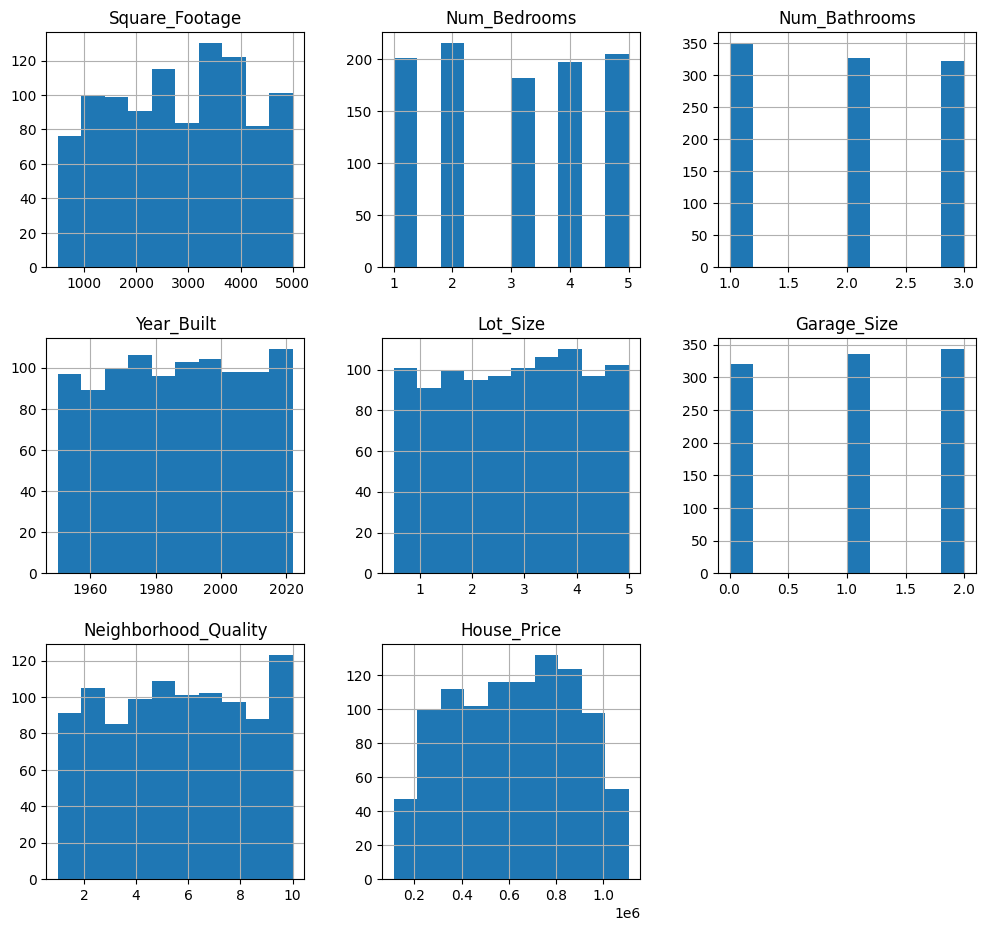

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df.hist(figsize=(12,11))
plt.show()

**Bivariate Analysis**

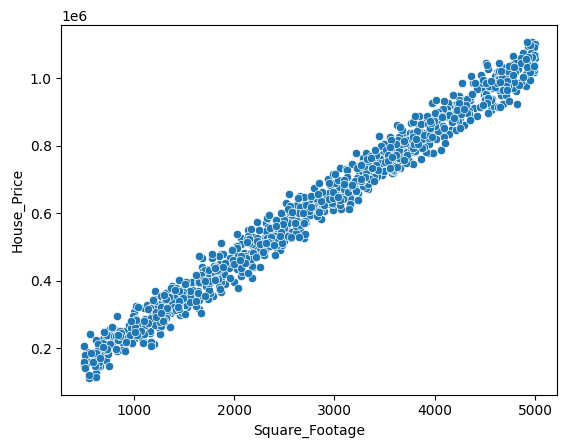

In [ ]:
sns.scatterplot(x="Square_Footage", y="House_Price", data=df)
plt.show()

**Correlation Heatmap**

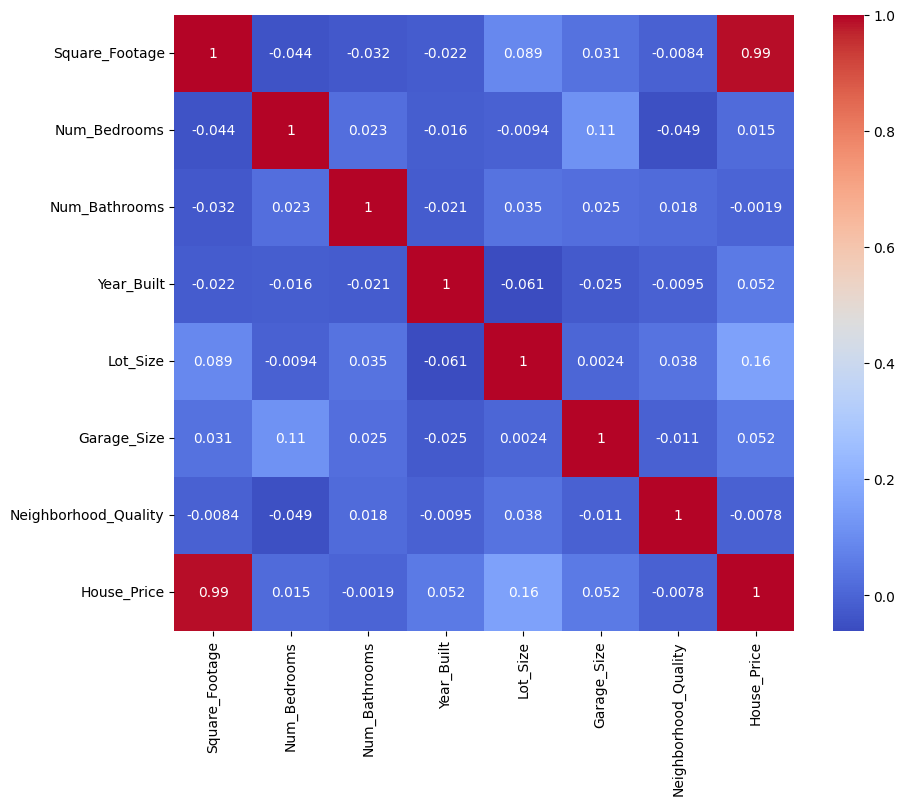

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

**Detect and Handle Outliers**

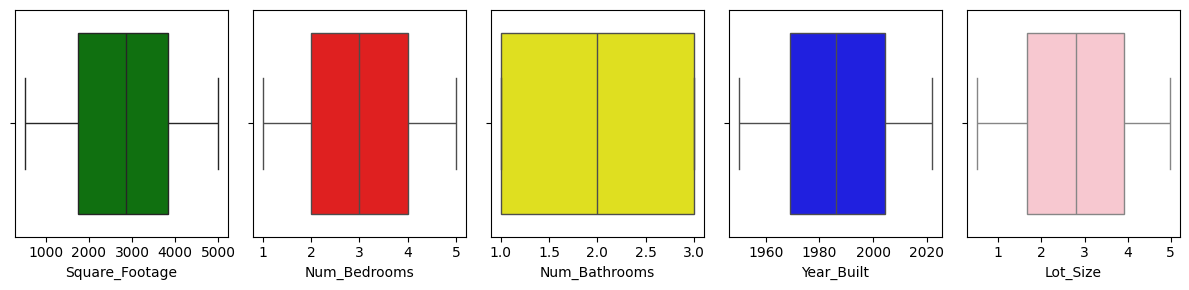

In [ ]:
#check which column has outliers
# Using 'df' instead of 'data' as the DataFrame name
temp_df = df[['Square_Footage','Num_Bedrooms','Num_Bathrooms','Year_Built','Lot_Size']]

fig , ax = plt.subplots(1,5,figsize=(12,3))
sns.boxplot(data=temp_df, x='Square_Footage', ax=ax[0], color='green')
sns.boxplot(data=temp_df, x='Num_Bedrooms', ax=ax[1], color='red')
sns.boxplot(data=temp_df, x='Num_Bathrooms', ax=ax[2], color='yellow')
sns.boxplot(data=temp_df, x='Year_Built', ax=ax[3], color='blue')
sns.boxplot(data=temp_df, x='Lot_Size', ax=ax[4], color='pink')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
# Select only numerical columns
num_cols = df.select_dtypes(include=np.number)
Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)
IQR = Q3 - Q1
# Keep only rows without outliers
df = df[~((num_cols < (Q1 - 1.5 * IQR)) | (num_cols > (Q3 + 1.5 * IQR))).any(axis=1)]
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
print("Remaining rows:", df.shape)

Remaining rows: (1000, 8)


**Apply Encoding**

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index([], dtype='object')


In [ ]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


>No categorical columns were found in the dataset, so encoding was not required.

**Apply Log Transformation**

In [ ]:
# Applying log transformation to the correct target column 'House_Price'
df['House_Price'] = np.log(df['House_Price'])
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,0.925818
1,4272,3,3,2016,4.753014,1,6,0.964973
2,3592,1,2,2016,3.634823,0,9,0.958374
3,966,1,2,1977,2.730667,1,8,0.921562
4,4926,2,1,1993,4.699073,0,8,0.966507


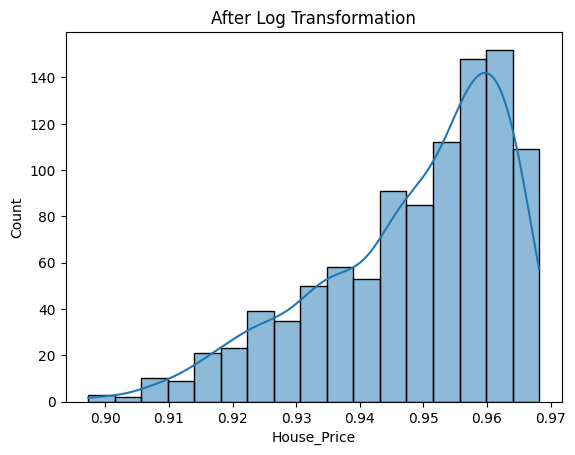

In [ ]:
sns.histplot(df['House_Price'], kde=True)
plt.title("After Log Transformation")
plt.show()

In [ ]:
df['House_Price'].describe()

,House_Price
count,1000.000000
mean,0.948384
std,0.014736
min,0.897303
25%,0.939025
50%,0.952264
75%,0.960101
max,0.968201


**Separate Features and Target Variable**

In [ ]:
X = df.drop('House_Price', axis=1)
y = df['House_Price']
X.head()


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,1360,2,1,1981,0.599637,0,5
1,4272,3,3,2016,4.753014,1,6
2,3592,1,2,2016,3.634823,0,9
3,966,1,2,1977,2.730667,1,8
4,4926,2,1,1993,4.699073,0,8


In [ ]:
print(X.shape)
print(y.shape)

(1000, 7)
(1000,)


**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
757,2119,2,1,2007,2.334721,0,4
828,3145,2,1,1955,1.145279,2,5
179,646,1,1,1956,2.310507,2,4
200,2556,4,1,1983,4.771403,2,8
982,4677,4,3,1964,2.017863,1,1


In [ ]:
print(X_train.shape)
print(X_test.shape)

(800, 7)
(200, 7)


**Apply Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Since X_train is now a numpy array, we use slicing instead of .head()
print(X_train[:5])
print(X_test[:5])

**Train Regression Models**
1. **Linear Regression**


In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

1. **KNN Regression**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [ ]:
print(y_pred_lr[:5])
print(y_pred_knn[:5])

[13.48762191 12.54541903 12.46226681 12.76113244 12.40715427]
[13.55132167 12.61342102 12.71433412 12.70172539 12.46098044]


**Evaluate Models Using**

● MAE (Mean Absolute Error)

● MSE (Mean Squared Error)

● RMSE (Root Mean Squared Error)

● MAPE

● R² Score

● Adjusted r2

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    # Calculate Adjusted R2
    n = len(y_test)
    p = X.shape[1] # Number of features
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAPE:", mape)
    print("R2:", r2)
    print("Adjusted r2:", adj_r2)

print("Linear Regression:")
evaluate(y_test, y_pred_lr)

print("\nKNN Regression:")
evaluate(y_test, y_pred_knn)

Linear Regression:
MAE: 0.09516172149841909
MSE: 0.013801796744035357
RMSE: 0.1174810484462722
MAPE: 0.7279964880439581
R2: 0.9404508454744029
Adjusted r2: 0.9382797825489906

KNN Regression:
MAE: 0.12684555548056736
MSE: 0.03196269523520927
RMSE: 0.17878113780600366
MAPE: 0.9808952746467915
R2: 0.8620939350930086
Adjusted r2: 0.8570661098099412


**Model Comparison Table**

In [ ]:
import pandas as pd
def get_metrics(y_test, y_pred):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import numpy as np

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    n = len(y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    return [mae, mse, rmse, mape, r2, adj_r2]
results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "MAPE", "R2", "Adjusted R2"],
    "Linear Regression": get_metrics(y_test, y_pred_lr),
    "KNN Regression": get_metrics(y_test, y_pred_knn)
})
results

,Metric,Linear Regression,KNN Regression
0,MAE,0.095162,0.126846
1,MSE,0.013802,0.031963
2,RMSE,0.117481,0.178781
3,MAPE,0.727996,0.980895
4,R2,0.940451,0.862094
5,Adjusted R2,0.938280,0.857066


In [ ]:
# Perform cross validation for all models
from sklearn.model_selection import cross_val_score

cv_results = {}

cv_results["Linear Regression"] = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2").mean()
cv_results["KNN Regression"] = cross_val_score(KNeighborsRegressor(), X, y, cv=5, scoring="r2").mean()

cv_df = pd.DataFrame(cv_results.items(), columns=["Model", "Cross Validation R2"])
cv_df.sort_values(by="Cross Validation R2", ascending=False)

,Model,Cross Validation R2
1,KNN Regression,0.977393
0,Linear Regression,0.926199


**Actual vs Predicted Plot**

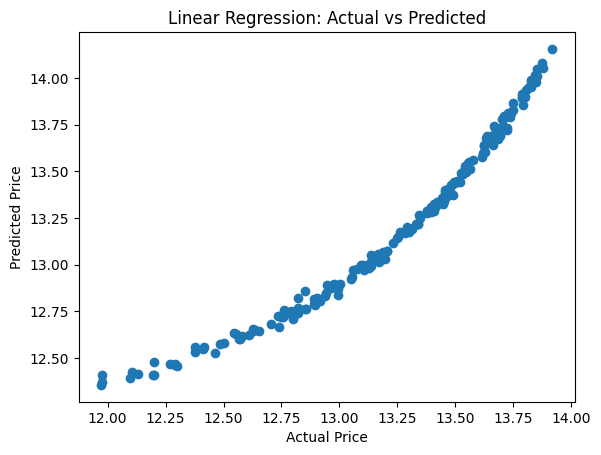

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [ ]:
# Compare actual and predicted house prices
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})
comparison.head(10)

,Actual,Predicted
0,13.534025,13.487622
1,12.412847,12.545419
2,12.290735,12.462267
3,12.857471,12.761132
4,12.197053,12.407154
5,13.681815,13.672233
6,13.787664,13.893396
7,13.143213,13.036638
8,13.101335,12.997788
9,13.450618,13.343550


**Error Comparison Chart**

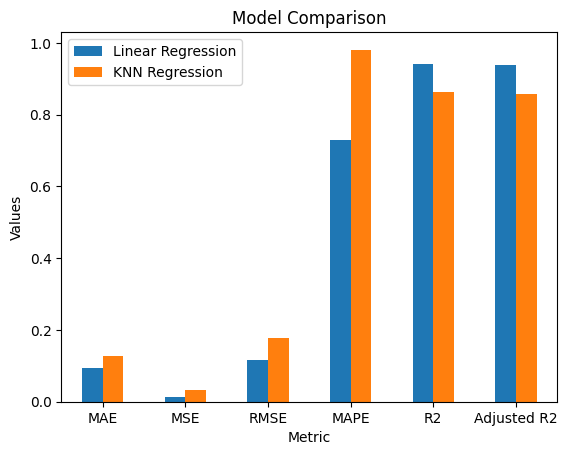

In [ ]:
results.set_index("Metric")[["Linear Regression", "KNN Regression"]].plot(kind='bar')
plt.title("Model Comparison")
plt.ylabel("Values")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Print final conclusion
# We transpose the 'results' DataFrame to easily sort by the R2 metric
comparison = results.set_index('Metric').T
best_model_name = comparison['R2'].idxmax()
best_model_stats = comparison.loc[best_model_name]

print(f"Best Model: {best_model_name}")
print(best_model_stats)

Best Model: Linear Regression
Metric
MAE            0.095162
MSE            0.013802
RMSE           0.117481
MAPE           0.727996
R2             0.940451
Adjusted R2    0.938280
Name: Linear Regression, dtype: float64
